# EDA, limpieza y análisis de datos sobre la vegetación de la Región de Biobío

En este notebook realizaremos un Análisis Exploratorio de Datos (EDA) sobre la información obtenida del reporte *Catastro de los Recursos Vegetacionales Nativos de Chile*, específicamente del Cuadro 5 (página 33 del documento, página 17 del pdf). Este cuadro contiene información sobre la superficie cubierta por distintos tipos de vegetación de cada región del país. 

Posteriormente, llevaremos a cabo un proceso de limpieza y transformación de los datos para facilitar su análisis.

### Objetivos
* Importar correctamente la tabla desde el documento pdf.
* Explorar y describir las características principales del dataset.
* Limpiar y transformar los datos.
* Responder a las preguntas ¿Qué tipos de cobertura vegetal dominan en la Región del Biobío? y ¿cómo podrían influir en el riesgo de propagación de incendios?

### Fuente
Los datos fueron obtenidos del reporte [Catastro de los Recursos Vegetacionales Nativos de Chile](https://sit.conaf.cl/varios/Catastros_Recursos_Vegetacionales_Nativos_de_Chile_Nov2021.pdf). Se utilizó específicamente el Cuadro 5 ubicado en la página 33 del documento, página 17 del pdf.

### Diccionario de variables
| Columna             | Descripción | 
|----------|-------------|
| Región              | Región administrativa del país  |
| Plantación forestal | Superficie cubierta por plataciones forestales, expresada en hectáreas (ha)|
| Bosque Nativo       | Superficie cubierta por bosque nativo, expresada en hectáreas (ha) |
| Bosque Mixto*       | Superficie cubierta por bosque mixto*, expresada en hectáreas (ha) |
| Total               | Superficie cubierta total, expresada en hectáreas (ha) |

</small> Bosque nativo corresponde a la mezcla de dos situaciones: 
- Mezcla de bosque nativo (adulto o renoval) y especies plantadas en proporciones que fluctúan entre el 33% al 66% de cubrimiento.
- Bosque nativo con exóticas asilvestradas, es decir, bosque nativo (adulto o renoval) y especies exóticas que se han regenerados en forma natural en proporciones que fluctúan entre 25% y 75% de cubrimiento para cada uno de las categorías que la constituyen.</small>

Antes de extraer la tabla, verificamos que el PDF contiene texto seleccionable mediante el comando: `pdffonts data\Catastros_Recursos_Vegetacionales_Nativos_de_Chile_Nov2021.pdf`. Lo anterior confirma que la información puede extraerse directamente desde el documento.

## 1. Configuración e Inicialización

In [1]:
# Librerias
# Manipulación de datos
import pdfplumber
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades
from pathlib import Path

### 1.1 Rutas del proyecto

In [2]:
# Path al archivo definido de forma relativa,
# de esta forma el notebook funciona no importa quien lo corra.
NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / 'data'

### 1.2 Extracción de la tabla desde el pdf

Definido el documento PDF desde el cual extraeremos la información, utilizamos la libreria `pdfplumber` para identificar automáticamente la tabla que necesitamos.

Buscamos por texto ('cuadro 5') en vez de número de página porque la numeración impresa no coincide con el índice real del PDF.

In [3]:
# Identificamos la ruta del PDf
DATA_FILE = DATA_DIR / 'Catastros_Recursos_Vegetacionales_Nativos_de_Chile_Nov2021.pdf'

In [4]:
# Esta celda puede tomar alrededor de 30seg

with pdfplumber.open(DATA_FILE) as pdf:
    texto_completo = ""
    for i, page in enumerate(pdf.pages):
        texto = page.extract_text() or ''
        if 'Cuadro 5' in texto:  # Donde colocamos el texto a buscar
            print(f'Encontrado en página índice {i} (página real {i+1})')

Encontrado en página índice 14 (página real 15)
Encontrado en página índice 16 (página real 17)


A continuación, visualizamos la tabla detectada para evaluar la calidad de la extracción.

In [5]:
with pdfplumber.open(DATA_FILE) as pdf:
    page = pdf.pages[16]  # índice 0-based, página real 17
    tabla = page.extract_tables()
    
    for fila in tabla[0]:
        print(fila)

['Tarapacá', '29.264,2', '33.246,4', '0,0', '62.510,6']
[None, '3.049,9', '11.899,3', '0,0', '14.949,2']
['Atacama', '276,4', '3.224,2', '0,0', '3.500,6']
[None, '12.285,1', '48,474,9', '886,4', '61.646,4']
['Valparaíso', '68.757,9', '484.115,7', '724,6', '553.598,1']
[None, '9.181,0', '363.955,3', '218,0', '373.354,3']
['O’Higgins', '130.536,4', '459.309,1', '545,7', '590.391,2']
[None, '634.893,5', '581.515,3', '28.674,8', '1.245.083,6']
['Ñuble', '380.714,9', '247.979,8', '17.051,8', '645.746,5']
[None, '875.178,4', '597.572,7', '51.635,9', '1.524.387,0']
['La Araucanía', '632.289,0', '964.152,9', '47.639,5', '1.644.081,3']
[None, '208.775,2', '908.530,7', '17.866,0', '1.135.171,9']
['Los Lagos', '96.598,8', '2.827.436,4', '12.799,3', '2.936.834,5']
[None, '32.017,3', '4.398.744,8', '1.083,0', '4.431.845,1']
['Magallanes y de\nla Antártica', '286,2', '2.760.176,6', '0,0', '2.760.462,8']
[None, '', '', '', '']
[None, '', '', '', '']
['Total', '3.114.125', '14.737.485', '179.125', '18

Si bien la mayoría de los valores numéricos fue extraída correctamente, observamos que algunas filas presentan problemas de reconocimiento. En particular, la fila correspondiente a la región de Arica y Parinacota no fue recuperada correctamente y algunas regiones aparecen incompletas.

Dado que el dataset final contiene información de solo 16 regiones y que nuestro objetivo principal es el análisis de los datos, optamos por reconstruir manualmente la tabla utilizando como base la información extraída automáticamente y verificándola contra la fuente original.

In [6]:
# Reconstruccion dataset con comparación visual con el PDF
datos = [
    ['Arica y Parinacota', '20,8', '47.151,3', '0,0', '47.172,1'],
    ['Tarapacá', '29.264,2', '33.246,4', '0,0', '62.510,6'],
    ['Antofagasta', '3.049,9', '11.899,3', '0,0', '14.949,2'],
    ['Atacama', '276,4', '3.224,2', '0,0', '3.500,6'],
    ['Coquimbo', '12.285,1', '48.474,9', '886,4', '61.646,4'],
    ['Valparaíso', '68.757,9', '484.115,7', '724,6', '553.598,1'],
    ['Metropolitana', '9.181,0', '363.955,3', '218,0', '373.354,3'],
    ["O'Higgins", '130.536,4', '459.309,1', '545,7', '590.391,2'],
    ['Maule', '634.893,5', '581.515,3', '28.674,8', '1.245.083,6'],
    ['Ñuble', '380.714,9', '247.979,8', '17.051,8', '645.746,5'],
    ['Biobío', '875.178,4', '597.572,7', '51.635,9', '1.524.387,0'],
    ['La Araucanía', '632.289,0', '964.152,9', '47.639,5', '1.644.081,3'],
    ['Los Ríos', '208.775,2', '908.530,7', '17.866,0', '1.135.171,9'],
    ['Los Lagos', '96.598,8', '2.827.436,4', '12.799,3', '2.936.834,5'],
    ['Aysén', '32.017,3', '4.398.744,8', '1.083,0', '4.431.845,1'],
    ['Magallanes y de la Antártica', '286,2', '2.760.176,6', '0,0', '2.760.462,8'],
    ['Total', '3.114.125', '14.737.485', '179.125', '18.030.735'],
    ['Porcentaje Nacional', '17,27', '81,74', '0,99', '100']
]

# Vista preliminar
raw_df = pd.DataFrame(datos, columns=["region", "plantacion_forestal", "bosque_nativo", "bosque_mixto", "total"])
raw_df.head()

,region,plantacion_forestal,bosque_nativo,bosque_mixto,total
0,Arica y Parinacota,"20,8","47.151,3","0,0","47.172,1"
1,Tarapacá,"29.264,2","33.246,4","0,0","62.510,6"
2,Antofagasta,"3.049,9","11.899,3","0,0","14.949,2"
3,Atacama,"276,4","3.224,2","0,0","3.500,6"
4,Coquimbo,"12.285,1","48.474,9","886,4","61.646,4"


Complementamos la información con los datos de humedales del Cuadro 4, paginas 30-31 del documento (16 PDF)

In [7]:
with pdfplumber.open(DATA_FILE) as pdf:
    page = pdf.pages[15]  # índice 0-based, página real 17
    tabla = page.extract_tables()
    
    for fila in tabla[0]:
        print(fila)

['Superficie Regional por tipo de uso', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 'Año de Año de\nactualización publicación', None]
['Arica y Parinacota', '10.577.4', '1,3', '12.707,7', '0,4', '923.141,6', '3,1', '47.172,1', '0,3', '23.759,7', '2,8', '', '665.853,3', '3,8', '7.109,1', '0,2', '4.158,7', '0,3', '0,0', '0,0', '1.694.479,6', '2014', '2015']
['Tarapacá', '67.993,8', '8,5', '6.441,1', '0,2', '1.589.373,8', '5,3', '62.510,6', '0,3', '11.804,0', '1,4', '', '2.489.891,4', '14,4', '0,0', '0,0', '789,5', '0,1', '0,0', '0,0', '4.228.804,2', '2016', '2018']
['Antofagasta', '273.150,3', '34,4', '6.419,9', '0,2', '4.710.223,7', '15,6', '14.949,2', '0,1', '47.483,4', '5,5', '', '7.543.701,0', '43,6', '0,0', '0,0', '10.036,4', '0,7', '0,0', '0,0', '12.605.964,0', '2018-201

De esta tabla solo necesitamos el valor de la columnas humedales, por tanto con un `for` podemos seleccionar los datos

In [8]:
humedales = []

for fila in tabla[0]:
    primer_elemento = fila[0]
    if primer_elemento not in (None, ''):
        humedales.append([fila[0], fila[9]])

print(humedales)
print(len(humedales))

[['Superficie Regional por tipo de uso', None], ['Arica y Parinacota', '23.759,7'], ['Tarapacá', '11.804,0'], ['Antofagasta', '47.483,4'], ['Atacama', '8.919,4'], ['Coquimbo', '11.555,1'], ['Valparaíso', '9.850,8'], ['Metropolitana', '12.515,5'], ['O’Higgins', '6.627,7'], ['Maule', '2.774,0'], ['Ñuble', '978,3'], ['Biobío', '10.172,8'], ['La Araucanía', '19.977,9'], ['Los Ríos', '12.246,4'], ['Los Lagos', '56.643,6'], ['Aysén', '107.806,0'], ['Magallanes y de\nla Antártica', '511.811,6'], ['Total país', '854.896'], ['Porcentaje\nNacional', '1,1']]
19


Con los datos los añadiremos al final de la tabla. Esto es porque al modelo solo le interesa la cantidad de cobertura vegetal y su total. El dato de humedales es más contextual y visual.

In [9]:
# Eliminamos el primer elemento para que sea más facil convertirlo en df
humedales = humedales[1:]
print(humedales)

[['Arica y Parinacota', '23.759,7'], ['Tarapacá', '11.804,0'], ['Antofagasta', '47.483,4'], ['Atacama', '8.919,4'], ['Coquimbo', '11.555,1'], ['Valparaíso', '9.850,8'], ['Metropolitana', '12.515,5'], ['O’Higgins', '6.627,7'], ['Maule', '2.774,0'], ['Ñuble', '978,3'], ['Biobío', '10.172,8'], ['La Araucanía', '19.977,9'], ['Los Ríos', '12.246,4'], ['Los Lagos', '56.643,6'], ['Aysén', '107.806,0'], ['Magallanes y de\nla Antártica', '511.811,6'], ['Total país', '854.896'], ['Porcentaje\nNacional', '1,1']]


In [10]:
# Convertimos la lista en dataframe
df_humedales = pd.DataFrame(humedales, columns=['region', 'humedales'])

# Renombramos algunas regiones para que el merge funcione
# Abreviamos los nombres más largos para facilitar las etiquetas
abreviaciones = {
    'O’Higgins': "O'Higgins",
    'Magallanes y de\nla Antártica': "Magallanes y de la Antártica",
    'Total país': 'Total',
    'Porcentaje\nNacional': 'Porcentaje Nacional',
}

df_humedales["region"] = df_humedales["region"].replace(abreviaciones)


# Une con tu dataset principal usando 'region' como llave
raw_df = raw_df.merge(df_humedales, on='region', how='left')
raw_df.head()

,region,plantacion_forestal,bosque_nativo,bosque_mixto,total,humedales
0,Arica y Parinacota,"20,8","47.151,3","0,0","47.172,1","23.759,7"
1,Tarapacá,"29.264,2","33.246,4","0,0","62.510,6","11.804,0"
2,Antofagasta,"3.049,9","11.899,3","0,0","14.949,2","47.483,4"
3,Atacama,"276,4","3.224,2","0,0","3.500,6","8.919,4"
4,Coquimbo,"12.285,1","48.474,9","886,4","61.646,4","11.555,1"


## 2. Análisis exploratorio de datos (EDA)

Aqui empezamos el análisis exploratorio (EDA) de los datos.

### 2.2 Cargar el dataset a usar y vista preliminar

In [11]:
df = raw_df.copy()

df.head()

,region,plantacion_forestal,bosque_nativo,bosque_mixto,total,humedales
0,Arica y Parinacota,"20,8","47.151,3","0,0","47.172,1","23.759,7"
1,Tarapacá,"29.264,2","33.246,4","0,0","62.510,6","11.804,0"
2,Antofagasta,"3.049,9","11.899,3","0,0","14.949,2","47.483,4"
3,Atacama,"276,4","3.224,2","0,0","3.500,6","8.919,4"
4,Coquimbo,"12.285,1","48.474,9","886,4","61.646,4","11.555,1"


### 2.3 Estructura de los datos

In [12]:
print(df.shape)
df.info()

(18, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   region               18 non-null     object
 1   plantacion_forestal  18 non-null     object
 2   bosque_nativo        18 non-null     object
 3   bosque_mixto         18 non-null     object
 4   total                18 non-null     object
 5   humedales            18 non-null     object
dtypes: object(6)
memory usage: 992.0+ bytes


#### Inspección inicial

Al revisar la estructura del dataset, observamos lo siguiente:

- La tabla contiene las 16 regiones del país, además de dos filas adicionales que presentan totales nacionales y porcentaje acumulativo para cada categoría de cobertura vegetal.
- Las columnas`plantacion_forestal`, `bosque_nativo`, `bosque_mixto` y `total` fueron cargadas como texto en lugar de valores numéricos.
- Esto ocurre porque los valores utilizan puntos como separadores de miles.

Verificaremos esta situación en la siguiente celda.

### 2.4 Tipos de datos

In [13]:
# .to_frame().T para ver los tipos como una fila horizontal
# más facil de leer que la lista vertical por defecto 
df.dtypes.to_frame().T

,region,plantacion_forestal,bosque_nativo,bosque_mixto,total,humedales
0,object,object,object,object,object,object


Efectivamente, los valores correspondientes a superficies se encuentran almacenados como texto.

In [14]:
columnas = ["region", "plantacion_forestal", "bosque_nativo", "bosque_mixto", "total"]
for col in columnas:
    print(f"\n{col}:")
    print(df[col].head(10).tolist())


region:
['Arica y Parinacota', 'Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo', 'Valparaíso', 'Metropolitana', "O'Higgins", 'Maule', 'Ñuble']

plantacion_forestal:
['20,8', '29.264,2', '3.049,9', '276,4', '12.285,1', '68.757,9', '9.181,0', '130.536,4', '634.893,5', '380.714,9']

bosque_nativo:
['47.151,3', '33.246,4', '11.899,3', '3.224,2', '48.474,9', '484.115,7', '363.955,3', '459.309,1', '581.515,3', '247.979,8']

bosque_mixto:
['0,0', '0,0', '0,0', '0,0', '886,4', '724,6', '218,0', '545,7', '28.674,8', '17.051,8']

total:
['47.172,1', '62.510,6', '14.949,2', '3.500,6', '61.646,4', '553.598,1', '373.354,3', '590.391,2', '1.245.083,6', '645.746,5']


Dado que los nombres de las regiones son legibles y consistentes, mantendremos la columna region sin modificaciones y centraremos el proceso de limpieza en la conversión de las variables numéricas.

## 3. Limpieza

### 3.1 Cambiar valores texto a número si corresponde

In [15]:
# Importante: el orden afecta el resultado. Primero eliminamos los puntos que 
# marcan los miles y luego cambiamos la coma a punto decimal.
def limpiar_numero_cl(serie):
    return serie.str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

columnas_num = ['plantacion_forestal', 'bosque_nativo', 'bosque_mixto', 'total']

for col in columnas_num:
    if df[col].dtype == 'object' or df[col].dtype == 'str':  # solo si todavía es texto
        df[col] = limpiar_numero_cl(df[col])

print(df.dtypes.to_frame().T)
df.head()

   region plantacion_forestal bosque_nativo bosque_mixto    total humedales
0  object             float64       float64      float64  float64    object


,region,plantacion_forestal,bosque_nativo,bosque_mixto,total,humedales
0,Arica y Parinacota,20.8,47151.3,0.0,47172.1,"23.759,7"
1,Tarapacá,29264.2,33246.4,0.0,62510.6,"11.804,0"
2,Antofagasta,3049.9,11899.3,0.0,14949.2,"47.483,4"
3,Atacama,276.4,3224.2,0.0,3500.6,"8.919,4"
4,Coquimbo,12285.1,48474.9,886.4,61646.4,"11.555,1"


El tipo de datos de `humedales` no lo cambiamos para mantener la legibilidad visual.

### 3.2 Verificar ausencia de nulos y duplicados

In [16]:
# Verificar nulos y duplicados

nulos = df.isna().sum()
duplicados = df['region'].duplicated().sum()

print('Regiones duplicadas ' + str(duplicados))
print('Numero de nulos por Regiones')
nulos.to_frame().T

Regiones duplicadas 0
Numero de nulos por Regiones


,region,plantacion_forestal,bosque_nativo,bosque_mixto,total,humedales
0,0,0,0,0,0,0


#### Verificación

Tras completar el proceso de limpieza, verificamos que:

- Las columnas `plantacion_forestal`,`bosque_nativo`,`bosque_mixto` y `total` fueron convertidas correctamente a variables numéricas.
- No existen nulos ni duplicados en el dataset.

Por lo tanto, el dataset se encuentra listo para continuar con el análisis exploratorio y descriptivo.

## 4. Análisis Descriptivo

### 4.1 Descripción de datos

Para proteger la integridad del deploy actual de nuestra aplicación, separaremos el dataset que usaremos en la app (`df`) y el dataset que usaremos para el análisis (`df_vegetacion`).

De este último, se harán todas las transformaciones necesarias para la descripción de datos y gráficos, como por ejemplo, tener un dataset que solo incluya información por región (`df_regiones`).

In [17]:
# df_vegetacion es el que usaremos para descripción y graficos.
# df es el dataset completo que guardaremos más adelante
# Esto es para proteger el deploy de la app (que usa el dataset completo)

df_vegetacion = df.copy()
df_regiones = df_vegetacion[:-2]

df_regiones[-5:]

,region,plantacion_forestal,bosque_nativo,bosque_mixto,total,humedales
11,La Araucanía,632289.0,964152.9,47639.5,1644081.3,"19.977,9"
12,Los Ríos,208775.2,908530.7,17866.0,1135171.9,"12.246,4"
13,Los Lagos,96598.8,2827436.4,12799.3,2936834.5,"56.643,6"
14,Aysén,32017.3,4398744.8,1083.0,4431845.1,"107.806,0"
15,Magallanes y de la Antártica,286.2,2760176.6,0.0,2760462.8,"511.811,6"


Por ejemplo, ahora examinaremos las métricas descriptivas del dataset como promedio (mean), cuartiles, máximos, entre otras. La presencia de las filas Total y Porcentaje Nacional afecta la claridad de la comparación de la cobertura vegetal de las regiones. Por ende, para esta sección trabajaremos con el dataset `df_regiones`. Mientras que `df_vegetacion` se incluirá cuando hagamos análisis comparativo a nivel país.

In [18]:
# Dado que queremos estudiar la vegetacion de cada una de las regiones
# las filas Total y porcentaje nacional afectan las metricas
# para más claridad en el análisis las sacaremos de momento

resumen = df_regiones.describe()

resumen[columnas_num] = resumen[columnas_num].map(lambda x: f'{x:,.2f}')

resumen

,plantacion_forestal,bosque_nativo,bosque_mixto,total
count,16.00,16.00,16.00,16.00
mean,"194,632.81","921,092.84","11,195.31","1,126,920.95"
std,"281,005.49","1,277,568.73","17,376.77","1,282,039.53"
min,20.80,"3,224.20",0.00,"3,500.60"
25%,"7,648.23","48,144.00",0.00,"62,294.55"
50%,"50,387.60","471,712.40",805.50,"618,068.85"
75%,"251,760.12","922,436.25","17,255.35","1,554,310.57"
max,"875,178.40","4,398,744.80","51,635.90","4,431,845.10"


In [19]:
top5 = df_regiones.nlargest(5, 'total')[columnas].reset_index(drop=True)
bottom5 = df_regiones.nsmallest(5, 'total')[columnas].reset_index(drop=True)

comparacion = pd.concat(
    [top5.rename(columns={
            "region": "Top 5 regiones"}),bottom5.rename(columns={
            "region": "Bottom 5 regiones"})],axis=1)

comparacion

,Top 5 regiones,plantacion_forestal,bosque_nativo,bosque_mixto,total,Bottom 5 regiones,plantacion_forestal,bosque_nativo,bosque_mixto,total
0,Aysén,32017.3,4398744.8,1083.0,4431845.1,Atacama,276.4,3224.2,0.0,3500.6
1,Los Lagos,96598.8,2827436.4,12799.3,2936834.5,Antofagasta,3049.9,11899.3,0.0,14949.2
2,Magallanes y de la Antártica,286.2,2760176.6,0.0,2760462.8,Arica y Parinacota,20.8,47151.3,0.0,47172.1
3,La Araucanía,632289.0,964152.9,47639.5,1644081.3,Coquimbo,12285.1,48474.9,886.4,61646.4
4,Biobío,875178.4,597572.7,51635.9,1524387.0,Tarapacá,29264.2,33246.4,0.0,62510.6


#### Conclusiones

A partir de las estadísticas descriptivas, podemos observar lo siguiente:

- Existe una gran variabilidad en todas las variables analizadas. Esto se explica por la diversidad geográfíca de Chile: mientras regiones del norte como Arica y Parinacota, Antofagasta y Coquimbo presentan una superficie forestal reducida, regiones del centro-sur y sur concentran gran parte de la cobertura vegetal del país.
- La Región del Biobío, objeto de estudio de este proyecto, corresponde a la cuarta region con mayor cobertura vegetal del país. Ya que la vegetación constituye el principal combustible disponible para la propagación del fuego, una mayor superficie cubierta por vegetación puede favorecer el desarrollo y expanción de incendios bajo condiciones ambientales propicias.

### 4.2 Top 5 regiones con más superficie de cada tipo de cobertura vegetal

In [20]:
top5_nativo = df_regiones.nlargest(5, 'bosque_nativo')[['region','bosque_nativo']].reset_index(drop=True)
top5_forestal = df_regiones.nlargest(5, 'plantacion_forestal')[['region','plantacion_forestal']].reset_index(drop = True)
top5_mixto = df_regiones.nlargest(5, 'bosque_mixto')[['region','bosque_mixto']].reset_index(drop=True)

comparacion = pd.concat(
    [top5_nativo.rename(columns={
            "region": "Top 5 regiones Nativo"}),
     top5_forestal.rename(columns={
            "region": "Top 5 regiones Forestal"}), 
     top5_mixto.rename(columns={
            "region": "Top 5 regiones Mixto"})],axis=1)

comparacion

,Top 5 regiones Nativo,bosque_nativo,Top 5 regiones Forestal,plantacion_forestal,Top 5 regiones Mixto,bosque_mixto
0,Aysén,4398744.8,Biobío,875178.4,Biobío,51635.9
1,Los Lagos,2827436.4,Maule,634893.5,La Araucanía,47639.5
2,Magallanes y de la Antártica,2760176.6,La Araucanía,632289.0,Maule,28674.8
3,La Araucanía,964152.9,Ñuble,380714.9,Los Ríos,17866.0
4,Los Ríos,908530.7,Los Ríos,208775.2,Ñuble,17051.8


Observaciones:

Como podemos observar, la Región del Biobío presenta la mayor superficie de plantaciones forestales y de bosque mixto del país.

Este resultado respalda la decisión de utilizar la región como caso de estudio para el proyecto, ya que la abundancia de cobertura vegetal implica una mayor disponibilidad de combustible para la propagación de incendios forestales.

### 4.3 Gráfico de barras cobertura vegetal de cada región

In [21]:
# Variables para los graficos de vegetación
columnas_veg = ['plantacion_forestal', 'bosque_nativo', 'bosque_mixto']

# Abreviamos los nombres más largos para facilitar las etiquetas
abreviaciones = {
    "Arica y Parinacota": "Arica y Par",
    "Magallanes y de la Antártica": "Magallanes y Ant",
}

df_regiones["region"] = df_regiones["region"].replace(abreviaciones)

df_regiones[-5:]

C:\Users\Avelyn\AppData\Local\Temp\ipykernel_27304\2163630834.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regiones["region"] = df_regiones["region"].replace(abreviaciones)


,region,plantacion_forestal,bosque_nativo,bosque_mixto,total,humedales
11,La Araucanía,632289.0,964152.9,47639.5,1644081.3,"19.977,9"
12,Los Ríos,208775.2,908530.7,17866.0,1135171.9,"12.246,4"
13,Los Lagos,96598.8,2827436.4,12799.3,2936834.5,"56.643,6"
14,Aysén,32017.3,4398744.8,1083.0,4431845.1,"107.806,0"
15,Magallanes y Ant,286.2,2760176.6,0.0,2760462.8,"511.811,6"


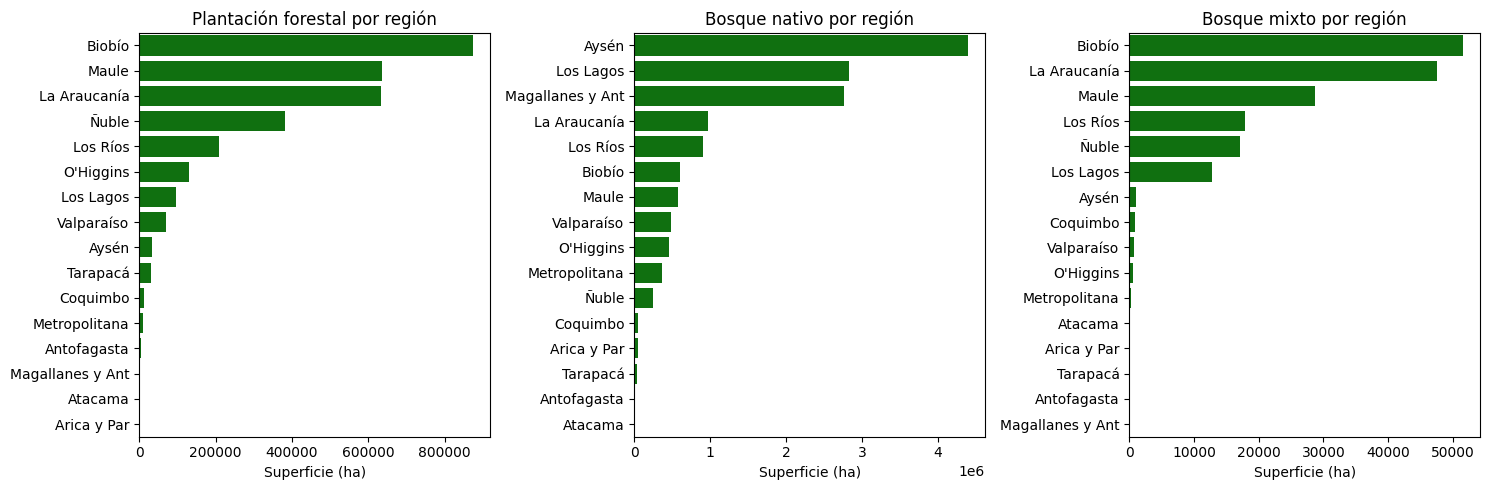

In [22]:
# Tres subplots
fig, axs = plt.subplots(1,3,figsize=(15, 5))

titulos = [
    "Plantación forestal por región",
    "Bosque nativo por región",
    "Bosque mixto por región"
    ]

for ax, var, titulo in zip(axs, columnas_veg, titulos):

    datos = df_regiones.sort_values(
        by=var,
        ascending=False
    )

    sns.barplot(
        data=datos,
        x=var,
        y="region",
        ax=ax,
        color="green"
    )

    ax.set_title(titulo)
    ax.set_xlabel("Superficie (ha)")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### Conclusiones
Ponemos comprobar que la Región del Biobío lidera la cobertura vegetal en las categorias de platanción forestal y bosque mixto. También vemos que es la sexta región con más superficie de bosque nativo del país.

### 4.4 Pie Chart proporcion de cada tipo de cobertura vegetal para la Región del Biobío

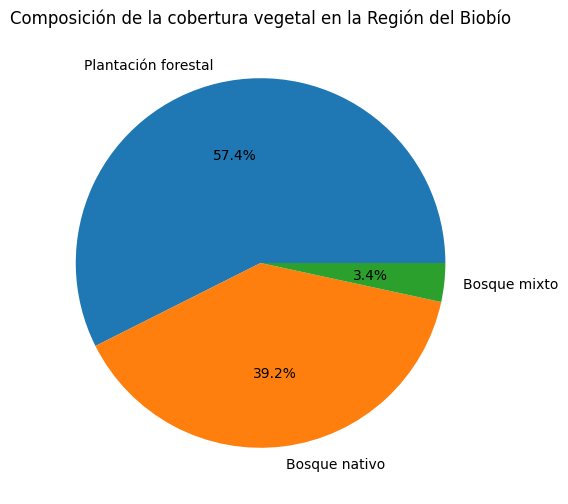

In [28]:
df_biobio = df_regiones[
    df_regiones["region"] == "Biobío"
]

valores = [
    df_biobio["plantacion_forestal"].iloc[0],
    df_biobio["bosque_nativo"].iloc[0],
    df_biobio["bosque_mixto"].iloc[0]
]

labels = [
    "Plantación forestal",
    "Bosque nativo",
    "Bosque mixto"
]

plt.figure(figsize=(6,6))

plt.pie(
    valores,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title(
    "Composición de la cobertura vegetal en la Región del Biobío"
)

plt.show()

#### Conclusiones
Como se pudo sospechar previamente, la gran mayoría de la cobertura vegetal de la Región del Biobío corresponde a plantaciones forestales con un 57.4%, seguido de bosque nativo con un 37.2% y bosque mixto con un 3.4%. En la siguiente sección hablaremos del modelo de propagación usado y las consecuencias de esta gran distribución de plantaciones forestales.

### 4.5 Modelo de Rothermel (1972) y modelo de simulación

Nuestro modelo es una versión simplificada de la ecuación de fluidos complejos del físico Richard Rothermel ("Rothermel, R. C. (1972). A mathematical model for predicting fire spread in wildland fuels. USDA Forest Service Research Paper INT-115."), reduciendo variables de laboratorio complejas (como la carga molecular o densidad de empaquetamiento) a un sistema optimizado de pesos ponderados lineales para garantizar una ejecución fluida:

La formula en su versión completa tiene la siguiente forma:
$$  R = \frac{I_R \cdot \xi \cdot (1 + \Phi_w + \Phi_s)}{\rho_b \cdot \epsilon \cdot Q_{ig}} $$

Donde $ R $  es la velocidad de propagación frontal, $ I_R $ la intensidad de reacción química, $\xi$ es la eficiencia de propagación, $\Phi_w$ el factor de empuje por viento. $\Phi_s$ el factor de empuje por pendiente del terreno, $\rho_b$ es la densidad aparente de combustible, $\epsilon$ el factor de calentamiento efectivo y $Q_{ig} $ La energía de ignición (pirolisis vegetal).
Dado lo complejo que es obtener muchas de estas variables ya que requieren parámetros microscópicos de laboratorio, imposibles de medir en tiempo real para toda la región, diseñamos un sistema matricial ponderado. Este asigna un factor de peligro relativo a cada covertura vegetal según su inflamabilidad real e histórica en la región, restando así el impacto de las barreras naturales como lo son los humedales.

Nuestra equación se termina reduciendo a 

$$ v_{fuego} = 0.5 + \frac{4ip}{100} + \frac{3v_v}{100}$$
$$ ip = 0.3 v_v + 0.3c + 0.2 T° + 0.1 seq  + 0.1 p $$

Donde $v_{fuego}$ es la velocidad de propagación del fuego, $ip$ es el indice de gravedad, $v_v$ es la velocidad del viento, $c$ es un estimado del efecto de la cobertura vegetal de la región, $T°$ es la temperatura, $seq$ es la sequedad del ambiente ($1 - humedad$) y $p$ es la pendiente del relieve.

Muchas de estas variables serán dadas por el usuario para realizar la simulación, si embargo podemos estimar el efecto de la cobertura vegetal con nuestros datos.





### 4.6 Efecto del tipo de cobertura vegetal

El factor $c$, que es un estimado del efecto que la cobertura vegetal de la región, lo calculamos de la siguiente forma:

$$ c = \frac{1.0cv_{plantacion} + 0.8cv_{mixto} + 0.6cv_{nativo}}{cv_{total}}\cdot100$$

donde $cv$ son la superficie en hectáreas de cada tipo de cobertura vegetal, plantaciones forestales, bosque mixto, bosque nativo, y la suma total, todo en hectareas.

Las razones de estas ponderaciones se dan a continuación y fueron basadas en el comportamiento físico del fuego y criterios técnicos que utiliza la CONAF para evaluar el peligro de incendios de Chile.

* Plantaciones forestales (coef. 1.0) 
  Se le asigna el peso máximo debido a:
  * Continuidad horizontal y vertical: Las plantaciones tienen un efecto de "combustible continuo" debido a su alta densidad de siembra y forma homogénea, lo que permite al fuego propagarse sin barreras naturales.
  * Baja retención de humedad: Estos suelos tienden a ser más secos y acumular mucho material fino muerto en el piso, lo que facilita la ignición en condiciones calurosas.
  * Desprendimiento de pavesas: El eucalipto, por ejemplo, desprende corteza encendida que vuela con el viento, generando focos secundarios a gran distancia.
* Bosque Mixto (coef 0.8)
  Recibe un peso intermedio porque combina características de ambos tipos de vegetación.
  * Representa zonas de transición o degradación donde conviven especies nativas con introducidas.
  * Al tener una estructura menos homogénea, el avance del fuego es moderado, pero sigue representando un gran peligro si hay estrés hídrico (sequedad) en la zona.
* Bosque Nativo (coef 0.6)
  Se le asigna un menor peso dado que presenta características como:
  *  Biodiversidad y estratificación: Al estar compuesto de múltiples especies, el combustible es heterogéneo, lo que dificulta el avance uniforme del fuego.
  *  Mayor humedad interna: Los bosques nativos sanos preservan mejor la humedad del suelo y en su biomasa molecular, actuando como resistencia térmica natural que frena la velocidad de la ignición vegetal.
  

**Por estas razones, la enorme proporción de plantaciones forestales en la Región del Biobío representa una vulnerabilidad considerables a estos siniestros. Reafirmando nuestra decisión de escoger a la región como objeto de estudio.** 

### 4.7 Gráfico de barras comparativo: proporción de cobertura vegetal de la Región del Biobío vs el país

In [24]:
# Aqui sacamos la información de la region del biobío
# Usamos iloc porque necesitamos el valor escalar de la fila, no
# como un data frame
biobio = df_regiones[
    df_regiones["region"] == "Biobío"
].iloc[0]

# y ponderamos de acuerdo al total de la región
porc_biobio = [
    biobio["plantacion_forestal"] / biobio["total"] * 100,
    biobio["bosque_nativo"] / biobio["total"] * 100,
    biobio["bosque_mixto"] / biobio["total"] * 100
]

# Y esta es la razón de los dos dataframes, como buscamos comparar
# la Región del Biobío con la cobertura a nivel país, guardamos el dataframe
# que contenga esa información, en vez de estar todo el tiempo retirandola 
# de nuestro análisis
chile = df_vegetacion[
    df_vegetacion["region"] == "Total"
].iloc[0]

porc_chile = [
    chile["plantacion_forestal"] / chile["total"] * 100,
    chile["bosque_nativo"] / chile["total"] * 100,
    chile["bosque_mixto"] / chile["total"] * 100
]

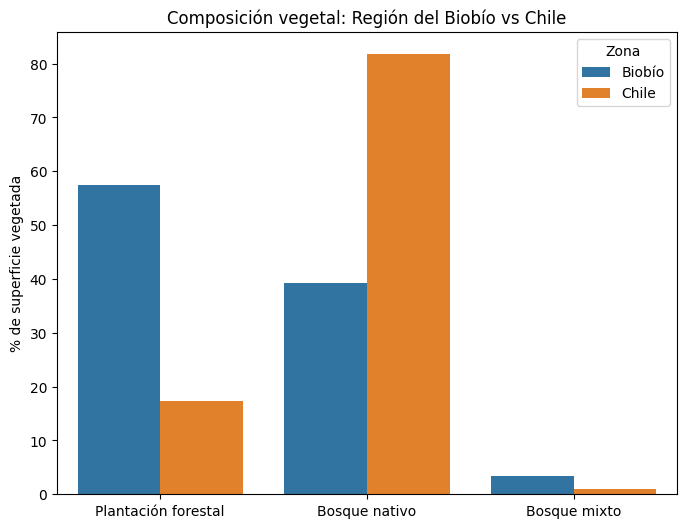

In [29]:
comparacion = pd.DataFrame({
    "Cobertura": [
        "Plantación forestal",
        "Bosque nativo",
        "Bosque mixto"
    ],
    "Biobío": porc_biobio,
    "Chile": porc_chile
})

comparacion = comparacion.melt(
    id_vars="Cobertura",
    var_name="Zona",
    value_name="Porcentaje"
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=comparacion,
    x="Cobertura",
    y="Porcentaje",
    hue="Zona"
)

plt.title(
    "Composición vegetal: Región del Biobío vs Chile"
)

plt.ylabel("% de superficie vegetada")
plt.xlabel("")

plt.show()

#### Conclusiones
La cantidad de plantación forestal de la Región del Biobío supera con creces la cantidad de de este tipo de cobertura que hay proporcionalmente a todo el país. Esto es un punto crítico, porque para nuestro modelo este tipo de cobertura vegetal es especialmente susceptible a la hora de un incendio. Esto refuerza la importancia de estudiar la Región del Biobío y el impacto que puedan tener los incendios en la población.

### Guardar dataset limpio

In [26]:
# Guardando el csv limpio con las columnas que sabemos que queremos

LIMPIO_FILE = DATA_DIR / 'bosques_chile_excel.csv'

df.to_csv(LIMPIO_FILE, index=False)

### Limpiar metadata

In [27]:
# Esto es solo para qeu el notebook se pueda ver en github
import json

with open('02_vegetacion.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

# Elimina la metadata de widgets si existe
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open('02_vegetacion.ipynb', 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1, ensure_ascii=False)